# 激光雷达直方图仿真 v13 (LiDAR Histogram Simulation) — RC 恢复 SPAD 模型

链路(激光→TX→信道→目标→RX)与 **v4 完全一致**; 逐光子蒙特卡洛(Monte Carlo, 蒙卡)、
宏像元(Macro Pixel)统计沿用 **v10/v11/v12**(模块 0–7 原样复用, 含 v12 的硬死时间引擎作对照)。

**v13 相对 v12 的变化 —— 用 RC 恢复模型取代硬死时间**
- v12 用**硬死时间(hard dead time)**: 雪崩后固定 14ns 内完全不响应, 之后瞬间满灵敏。
  这抹掉了 SPAD 恢复期的**部分灵敏**——真实器件恢复期仍能以较低概率触发较弱雪崩。
- v13 新增 **RC 恢复模型**(模块 7b, 更接近物理): 雪崩后过电压
  **Vov(OverVoltage, 过电压 = V_bias − V_br)** 通过淬灭电阻 R 与结电容 C_J 按 **RC 指数**恢复:
  $$V_{ov}(\Delta t)=V_{ov,max}\,(1-e^{-\Delta t/\tau}),\qquad \tau=R\,C_J$$
  - 恢复期来光子的触发概率 **PDE(Δt)=PDE_max · Vov(Δt)/Vov_max**(线性 PDE∝Vov);
  - 触发后**只有脉冲幅度(∝当前 Vov)≥ 阈值 Vth 才被读出电路计一次数**;
  - **仅计数事件复位**: 只有够阈值的计数事件才重置 Vov、重新开始 RC 恢复(亚阈弱雪崩不复位)。
- **参数**(本版设定): τ_RC = **6 ns**, Vth = **10% · Vov_max**, Vov_max = 3.3 V, reset = **仅计数事件**。
- 模块 8/9/11/12 全部改用 RC 引擎, 并**与 v12 硬死时间(14ns)对比**, 展示两模型差异。

**为什么 RC 更可靠(尤其本场景)**
- 本场景中心 SPAD 单 shot 入射约 64 光子、脉宽约 6ns(远短于恢复时间), 光子极密集。
- 硬死时间把恢复期一刀切死 ⇒ 严重低估计数(峰值区仅剩~6%); RC 允许恢复途中被较弱触发 ⇒ 更真实(~18%)。

> ⚠️ 运行方式: **Kernel → Restart & Run All**(从上到下顺序执行)。
> 宏像元方向锁定: **3 沿长边 y, 9 沿短边 x**(9×3, 沿长边 40 个, 每个 27 SPAD)。

## 模块 0 — 参数与常数

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

C_LIGHT = 2.99792458e8      # 光速 [m/s]
H_PLANCK = 6.62607015e-34   # 普朗克常数 [J·s]
D_PLOT_MAX = 300.0          # D 相关 plot 的统一距离范围 [m]

PARAMS = {
    # ---------- 激光源 ----------
    "laser": {
        "wavelength": 905e-9,   # 波长 [m]
        "amp_mode": "peak",     # "peak"=用 P_peak 定幅 / "energy"=用 E_pulse 定幅
        "P_peak": 235.0,        # 峰值光功率 [W]
        "E_pulse": 800e-9,      # 目标单脉冲能量 [J] (amp_mode="energy" 时生效)
        "tau_r": 0.7e-9,        # 双指数上升时间常数 [s]
        "tau_f": 1.9e-9,        # 双指数下降时间常数 [s]
        "x_L": 60e-6,           # 发光面 X 尺寸(慢轴, 1/e^2 全宽) [m]
        "y_L": 1150e-6,         # 发光面 Y 尺寸(快轴, 1/e^2 全宽) [m]
    },

    # ---------- TX 发射光学 ----------
    "tx": {
        "f_TX": 36e-3,          # 发射物镜焦距 [m]
        "D_TX": 12.7e-3,        # 发射通光口径 [m] -> w0 = D_TX/2
        "eta_coupling": 0.87,   # 发射角度耦合效率
        "T_TX": 0.92,           # 发射透过率
    },

    # ---------- 信道 / 大气 ----------
    "channel": {
        "alpha": 0.1e-3,        # 消光系数 @905nm [1/m]  (0.1/km≈晴朗)
        # 0.3e-3 小雨 / 0.6e-3 大雨 / 20e-3 大雾 / 60e-3 浓雾
    },

    # ---------- 目标 (多回波) ----------
    "target": {
        "echoes": [
            {"D": 30.0,  "rho": 0.10, "frac": 1.00, "tilt_deg": 0.0,  "name": "近处物体(边缘拦截)"},
            {"D": 120.0, "rho": 0.10, "frac": 0.00, "tilt_deg": 30.0, "name": "主目标(倾斜墙面)"},
            {"D": 200.0, "rho": 0.10, "frac": 0.00, "tilt_deg": 0.0,  "name": "远处背景"},
        ],
    },

    # ---------- RX 接收光学 ----------
    "rx": {
        "f_RX": 25e-3,          # 接收物镜焦距 [m]
        "D_RX": 13e-3,          # 接收口径 [m]
        "eta_RX": 0.82,         # 接收耦合效率
        "T_RX": 0.90,           # 接收透过率
        "T_filter": 0.90,       # 窄带滤光片透过率
        "filter_bw": 12e-9,     # 滤光片带宽 [m] (12 nm bandpass)
    },

    # ---------- SPAD 器件 ----------
    "spad": {
        "PDE": 0.30,            # 光子探测效率
        "DCR": 0.0e3,           # 单像元暗计数率 [cps]
        "jitter_sigma": 100e-12,# IRF 高斯 sigma [s]
    },

    # ---------- 方形 SPAD 阵列 ----------
    "spad_array": {
        "pitch": 10e-6,         # 方形像元间距 [m]
        "Nx": 9, "Ny": 120,  # 阵列规模
        "fill_factor": 1.00,    # 填充因子(=1 表示不计死区/假设微透镜完全补偿)
        "sum_pixels": "illuminated",  # "illuminated"仅被照像元 / "all"整阵列
    },

    # ---------- Macro Pixel 宏像元 Binning (v3 新增) ----------
    # 把 Bx×By 个物理像元合并成一个宏像元, 对应视场 iFOV_macro = B·pitch/f_RX.
    # 只有落在宏像元窗口内的回波像斑光被接收(超出部分丢失).
    # 坐标约定(全局一致): x=短边(发光区60µm→像斑~7µm), y=长边(发光区1150µm→像斑~122µm).
    # 本例: 6/9/12 沿 x(短边), 3 沿 y(长边).
    #   → x窗口60/90/120µm 远超像斑7µm ⇒ x方向都≈全收; y窗口固定30µm 罩不住122µm长条.
    #   ⇒ 三种收集比例几乎相同(~0.48), 差异只在背景像元数(18/27/36). 这是真实配置的物理结果.
    "macro": {
        "sizes_xy": [(6, 3), (9, 3), (12, 3)],   # (Bx 沿短边x, By 沿长边y) 的宏像元尺寸列表
    },

    # ---------- 环境光 (直接给辐照值, 不做 lux 光谱假设) ----------
    "ambient": {
        "enable": True,         # 是否计入环境光
        # 905nm 处光谱辐照度 [W/m²/nm]. 100klux 白天太阳 AM1.5 附近典型 ~0.5-0.7; 按你的实测改.
        "E_lambda": 0.68,
        "surface_rho": 0.10,    # 被观测目标面反射率(用于环境光漫反射, 可与 echo 不同)
    },

    # ---------- 直方图 / TCSPC ----------
    "hist": {
        "t_max": 2048e-9,       # 时间窗 [s] (~307 m)
        "bin_width": 1e-9,      # bin 宽 [s]
        "dt_fine": 10e-12,      # 卷积精细网格 [s]
        "N_shots": 10,          # 累加脉冲数
        "seed": 0,
    },
}

E_PHOTON = H_PLANCK * C_LIGHT / PARAMS["laser"]["wavelength"]
print(f"单光子能量 E_photon = {E_PHOTON:.3e} J  ({E_PHOTON/1.602e-19:.3f} eV)")
print(f"1 ns bin -> 距离分辨 {C_LIGHT*1e-9/2*100:.1f} cm;  时间窗 {PARAMS['hist']['t_max']*1e9:.0f} ns -> "
      f"最远 {PARAMS['hist']['t_max']*C_LIGHT/2:.0f} m")

单光子能量 E_photon = 2.195e-19 J  (1.370 eV)
1 ns bin -> 距离分辨 15.0 cm;  时间窗 2048 ns -> 最远 307 m


## 模块 1 — 激光源

空间：椭圆高斯 `S(x,y)=exp(-2x²/w_x²-2y²/w_y²)`。此激光条 Y 为快轴(1150µm)更长。
时间：双指数 `p(t)=exp(-t/τ_f)-exp(-t/τ_r)`。

**脉宽定义**：主指标为 **上升沿10% → 下降沿10% 的全宽**（记作 W_10-10）。
幅度基准 `amp_mode`：`"peak"` 锁 P_peak，能量由 `E=∫P dt` 算出。

[amp_mode = peak]
峰值功率 P_peak          = 235.0 W
单脉冲能量 E             = 799.4 nJ
脉宽 W(10%-10% 全宽)     = 6.31 ns   ← v2 主指标
  (参考 FWHM 半高全宽     = 2.94 ns)
上升(10-90%)=0.62 ns   下降(90-10%)=4.61 ns   τ_eff=E/P=3.40 ns


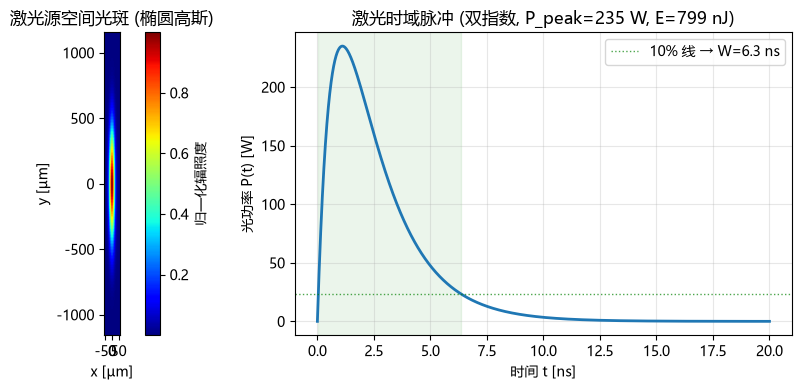

In [2]:
def spot_spatial(x, y, p=PARAMS):
    wx, wy = p["laser"]["x_L"] / 2.0, p["laser"]["y_L"] / 2.0
    return np.exp(-2.0 * (x**2) / wx**2 - 2.0 * (y**2) / wy**2)

def _pulse_norm(p=PARAMS):
    tr, tf = p["laser"]["tau_r"], p["laser"]["tau_f"]
    t_peak = np.log(tf / tr) / (1.0 / tr - 1.0 / tf)
    s_peak = np.exp(-t_peak / tf) - np.exp(-t_peak / tr)
    area_shape = tf - tr
    A = p["laser"]["E_pulse"] * s_peak / area_shape if p["laser"]["amp_mode"] == "energy" else p["laser"]["P_peak"]
    return A, s_peak, t_peak, area_shape

def pulse_temporal(t, p=PARAMS):
    tr, tf = p["laser"]["tau_r"], p["laser"]["tau_f"]
    A, s_peak, _, _ = _pulse_norm(p)
    tpos = np.clip(t, 0.0, None)
    shape = np.where(t >= 0, np.exp(-tpos / tf) - np.exp(-tpos / tr), 0.0)
    return A * np.clip(shape, 0.0, None) / s_peak

def pulse_metrics(p=PARAMS):
    """脉冲特征. 主指标 W_10_10 = 上升10%到下降10%的全宽."""
    t = np.linspace(0, 60e-9, 600001)
    P = pulse_temporal(t, p); pk = P.max(); i_pk = np.argmax(P)
    # 上升沿 10% 时刻 / 下降沿 10% 时刻
    t_rise10 = np.interp(0.1 * pk, P[:i_pk + 1], t[:i_pk + 1])
    td, Pd = t[i_pk:], P[i_pk:]
    t_fall10 = np.interp(0.1 * pk, Pd[::-1], td[::-1])
    W_10_10 = t_fall10 - t_rise10
    fwhm = (lambda a: a[-1] - a[0])(t[P >= 0.5 * pk])
    rise = np.interp(0.9 * pk, P[:i_pk + 1], t[:i_pk + 1]) - t_rise10
    fall = t_fall10 - np.interp(0.9 * pk, Pd[::-1], td[::-1])
    energy = np.trapezoid(P, t)
    return {"W_10_10": W_10_10, "FWHM": fwhm, "rise_10_90": rise, "fall_90_10": fall,
            "energy": energy, "peak": pk, "tau_eff": energy / pk,
            "t_rise10": t_rise10, "t_fall10": t_fall10}

_m = pulse_metrics()
print(f"[amp_mode = {PARAMS['laser']['amp_mode']}]")
print(f"峰值功率 P_peak          = {_m['peak']:.1f} W")
print(f"单脉冲能量 E             = {_m['energy']*1e9:.1f} nJ")
print(f"脉宽 W(10%-10% 全宽)     = {_m['W_10_10']*1e9:.2f} ns   ← v2 主指标")
print(f"  (参考 FWHM 半高全宽     = {_m['FWHM']*1e9:.2f} ns)")
print(f"上升(10-90%)={_m['rise_10_90']*1e9:.2f} ns   下降(90-10%)={_m['fall_90_10']*1e9:.2f} ns   τ_eff=E/P={_m['tau_eff']*1e9:.2f} ns")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
gx = np.linspace(-PARAMS["laser"]["x_L"], PARAMS["laser"]["x_L"], 200)
gy = np.linspace(-PARAMS["laser"]["y_L"], PARAMS["laser"]["y_L"], 200)
GX, GY = np.meshgrid(gx, gy)
im = ax[0].pcolormesh(GX * 1e6, GY * 1e6, spot_spatial(GX, GY), shading="auto", cmap="jet")
ax[0].set_title("激光源空间光斑 (椭圆高斯)")
ax[0].set_xlabel("x [µm]"); ax[0].set_ylabel("y [µm]"); ax[0].set_aspect("equal")
plt.colorbar(im, ax=ax[0], label="归一化辐照度")
tt = np.linspace(0, 20e-9, 3000)
ax[1].plot(tt * 1e9, pulse_temporal(tt), lw=2)
ax[1].axhline(_m["peak"]*0.1, color="g", ls=":", lw=1, alpha=0.7, label=f"10% 线 → W={_m['W_10_10']*1e9:.1f} ns")
ax[1].axvspan(_m["t_rise10"]*1e9, _m["t_fall10"]*1e9, color="g", alpha=0.08)
ax[1].set_title(f"激光时域脉冲 (双指数, P_peak={_m['peak']:.0f} W, E={_m['energy']*1e9:.0f} nJ)")
ax[1].set_xlabel("时间 t [ns]"); ax[1].set_ylabel("光功率 P(t) [W]")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 模块 2 — TX 发射光学

半发散角 = 几何项 ⊕ 衍射项：`θ_geom=尺寸/(2 f_TX)`，`θ_diff≈λ/(π w0)`，`w0=D_TX/2`。
瑞利距离 `z_R≈w0/θ`。

In [3]:
def tx_derived(p=PARAMS):
    x_L, y_L = p["laser"]["x_L"], p["laser"]["y_L"]
    f_TX = p["tx"]["f_TX"]; lam = p["laser"]["wavelength"]; w0 = p["tx"]["D_TX"] / 2.0
    tgx, tgy = x_L / (2 * f_TX), y_L / (2 * f_TX)
    tdf = lam / (np.pi * w0)
    tx_, ty_ = np.hypot(tgx, tdf), np.hypot(tgy, tdf)
    return {"theta_x": tx_, "theta_y": ty_, "theta_geom_x": tgx, "theta_geom_y": tgy,
            "theta_diff": tdf, "zR_x": w0 / tx_, "zR_y": w0 / ty_, "w0": w0,
            "eta_TX": p["tx"]["eta_coupling"] * p["tx"]["T_TX"]}

_tx = tx_derived()
print(f"半发散角  θ_x = {_tx['theta_x']*1e3:.4f} mrad,  θ_y = {_tx['theta_y']*1e3:.4f} mrad")
print(f"  (几何 {_tx['theta_geom_x']*1e3:.4f}/{_tx['theta_geom_y']*1e3:.4f} mrad, 衍射下限 {_tx['theta_diff']*1e3:.4f} mrad)")
print(f"瑞利距离  z_R,x = {_tx['zR_x']:.2f} m,  z_R,y = {_tx['zR_y']:.2f} m")
print(f"出光效率  η_TX = {_tx['eta_TX']:.3f}")

半发散角  θ_x = 0.8346 mrad,  θ_y = 15.9723 mrad
  (几何 0.8333/15.9722 mrad, 衍射下限 0.0454 mrad)
瑞利距离  z_R,x = 7.61 m,  z_R,y = 0.40 m
出光效率  η_TX = 0.800


## 模块 3 — 信道（大气 + 光斑扩展 + 飞行时间）

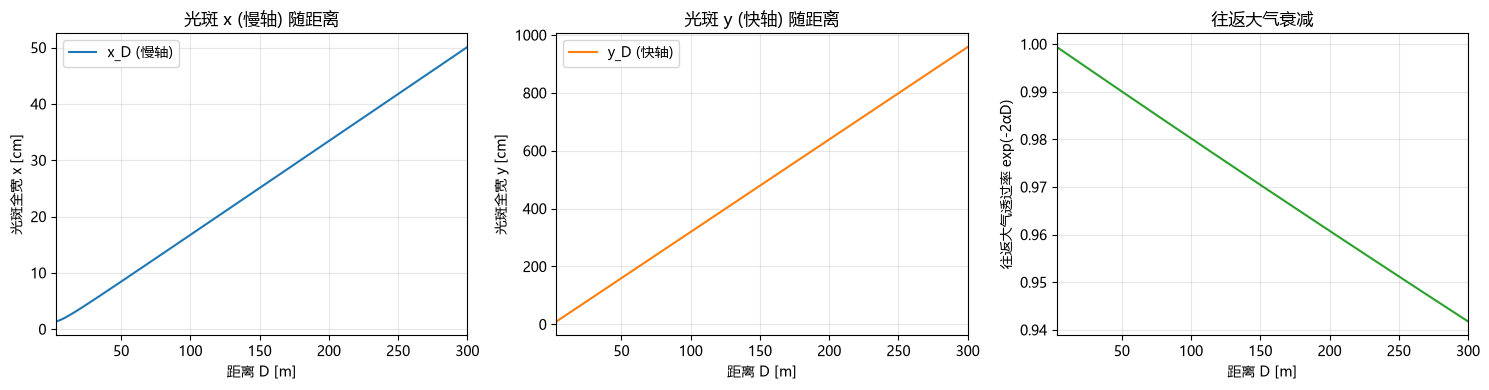

D=   30 m:  光斑   5.17 ×  95.84 cm,  t_ToF=  200.1 ns
D=  120 m:  光斑  20.07 × 383.34 cm,  t_ToF=  800.6 ns
D=  200 m:  光斑  33.41 × 638.89 cm,  t_ToF= 1334.3 ns


In [4]:
def atm_transmission(D, p=PARAMS):
    return np.exp(-p["channel"]["alpha"] * D)

def beam_spot_size(D, p=PARAMS):
    tx = tx_derived(p); w0 = tx["w0"]
    return (2 * w0 * np.sqrt(1 + (D / tx["zR_x"])**2),
            2 * w0 * np.sqrt(1 + (D / tx["zR_y"])**2))

def beam_area(D, p=PARAMS):
    x_D, y_D = beam_spot_size(D, p)
    return np.pi / 4.0 * x_D * y_D

def time_of_flight(D):
    return 2.0 * D / C_LIGHT

Ds = np.linspace(0.1, D_PLOT_MAX, 600)
xD = np.array([beam_spot_size(d)[0] for d in Ds])
yD = np.array([beam_spot_size(d)[1] for d in Ds])
_mvis3 = Ds >= 3.0    # 只画 D>=3m, 使自动 y 轴聚焦可见区间
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# 光斑 x (慢轴)
ax[0].plot(Ds[_mvis3], xD[_mvis3]*100, color="tab:blue", label="x_D (慢轴)")
ax[0].set_xlabel("距离 D [m]"); ax[0].set_ylabel("光斑全宽 x [cm]")
ax[0].set_title("光斑 x (慢轴) 随距离"); ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_xlim(3, D_PLOT_MAX)
# 光斑 y (快轴)
ax[1].plot(Ds[_mvis3], yD[_mvis3]*100, color="tab:orange", label="y_D (快轴)")
ax[1].set_xlabel("距离 D [m]"); ax[1].set_ylabel("光斑全宽 y [cm]")
ax[1].set_title("光斑 y (快轴) 随距离"); ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_xlim(3, D_PLOT_MAX)
# 往返大气衰减
ax[2].plot(Ds[_mvis3], atm_transmission(Ds[_mvis3])**2, color="tab:green")
ax[2].set_xlabel("距离 D [m]"); ax[2].set_ylabel("往返大气透过率 exp(-2αD)")
ax[2].set_title("往返大气衰减"); ax[2].grid(alpha=0.3); ax[2].set_xlim(3, D_PLOT_MAX)
plt.tight_layout(); plt.show()
for e in PARAMS["target"]["echoes"]:
    d = e["D"]; xd, yd = beam_spot_size(d)
    print(f"D={d:>5.0f} m:  光斑 {xd*100:6.2f} × {yd*100:6.2f} cm,  t_ToF={time_of_flight(d)*1e9:7.1f} ns")

## 模块 4 — 目标（反射率 + 朗伯漫反射 + 多回波）

朗伯 BRDF（Bidirectional Reflectance Distribution Function，双向反射分布函数）= ρ/π。
倾角展宽：`Δt=2 w tanφ/c`。

In [5]:
def lambertian_brdf(rho):
    return rho / np.pi

def echo_range_broadening_sigma(D, tilt_deg, p=PARAMS):
    x_D, y_D = beam_spot_size(D, p)
    w = 0.5 * np.hypot(x_D, y_D) / np.sqrt(2)
    dz = w * np.tan(np.deg2rad(tilt_deg))
    return (2.0 * dz / C_LIGHT) / 2.0

def check_frac_sum(p=PARAMS):
    s = sum(e["frac"] for e in p["target"]["echoes"])
    print(f"各回波拦截比例之和 = {s:.2f}  [{'OK' if s<=1+1e-9 else '⚠ >1 不物理'}];  余下 {max(0,1-s):.2f} 穿过")
    return s

check_frac_sum()
for e in PARAMS["target"]["echoes"]:
    sig = echo_range_broadening_sigma(e["D"], e["tilt_deg"])
    print(f"  {e['name']:<16} D={e['D']:>5.0f} m, ρ={e['rho']}, frac={e['frac']}, 倾角={e['tilt_deg']}° → 展宽σ={sig*1e12:.0f} ps")

各回波拦截比例之和 = 1.00  [OK];  余下 0.00 穿过
  近处物体(边缘拦截)       D=   30 m, ρ=0.1, frac=1.0, 倾角=0.0° → 展宽σ=0 ps
  主目标(倾斜墙面)        D=  120 m, ρ=0.1, frac=0.0, 倾角=30.0° → 展宽σ=2614 ps
  远处背景             D=  200 m, ρ=0.1, frac=0.0, 倾角=0.0° → 展宽σ=0 ps


## 模块 5 — RX 接收光学（像面光斑：几何 ⊕ 衍射）

### LiDAR 方程（扩展目标，1/D²）
$$P_{RX,k}(t)=P\!\left(t-\tfrac{2D_k}{c}\right)\cdot \eta_{TX}\cdot frac_k\cdot \frac{\rho_k}{\pi}\cdot \frac{A_{RX}}{D_k^2}\cdot e^{-2\alpha D_k}\cdot \eta_{RX}\cdot T_{RX}\cdot T_{filter}$$

### 像面光斑尺寸（几何 ⊕ 衍射）
RX 对**扩展目标面**成像。对 D≫f_RX 的目标，成像是"**角度→像面位置**"：像面尺寸 = 目标张角 × f_RX。
目标张角 = 光束在该处的角宽 `x_D(D)/D`（近场用完整高斯束，远场趋于恒定发散角 `x_L/f_TX`）。
几何像斑 `s_geom = (x_D/D)·f_RX`，再与**衍射艾里斑**（Airy disk）平方和合成：
`s = √(s_geom² + s_Airy²)`，`s_Airy = 2.44 λ (f_RX/D_RX)`。

**像斑为何与距离几乎无关、缩小倍率是多少？** 因为 `x_D ∝ D`（发散）而放大率 `m=f_RX/D ∝ 1/D`，
两者相乘 **D 抵消**，故远场像斑 ≈ `发光区 × f_RX/f_TX`。本例 `f_TX=36mm、f_RX=25mm`，
缩小倍率 `f_TX/f_RX ≈ 1.44×`：60µm→~42µm(短边 x)、1150µm→~800µm(长边 y)，再与艾里斑平方和。
（注：若 f_TX 远大于 f_RX，缩小倍率会大得多；缩小倍率完全由两焦距之比决定。）

> **旧版错误**：直接用"激光光斑物理尺寸 × 放大率 f_RX/D"当像斑，数值偏大且没有衍射下限。

接收孔径 A_RX = 1.327 cm²,  f/# = 1.92,  艾里斑直径 = 4.25 µm
  D=  30m: 像面光斑  43.26 ×  798.70 µm  → 被照像元 5×80=400
  D= 120m: 像面光斑  42.03 ×  798.63 µm  → 被照像元 5×80=400
  D= 200m: 像面光斑  41.97 ×  798.63 µm  → 被照像元 5×80=400
单像元 iFOV = 0.4000 mrad,  阵列 FOV = 3.6×48.0 mrad
探测效率 η=PDE×填充 = 0.300   累加像元数 n_sum=400 (模式='illuminated')


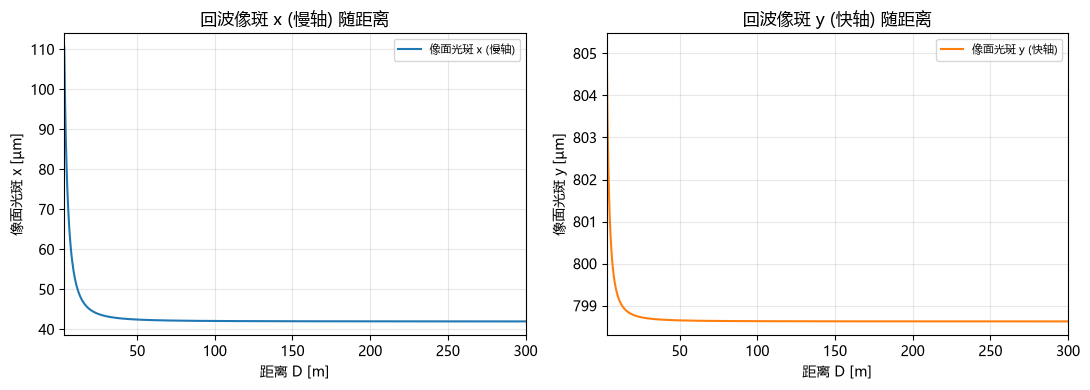

  近处物体(边缘拦截)       link=2.481e-09,  P_RX_peak=582.9781 nW
  主目标(倾斜墙面)        link=0.000e+00,  P_RX_peak=0.0000 nW
  远处背景             link=0.000e+00,  P_RX_peak=0.0000 nW


In [6]:
def rx_area(p=PARAMS):
    return np.pi * (p["rx"]["D_RX"] / 2.0)**2

def airy_diameter(p=PARAMS):
    """衍射极限像点(艾里斑)直径 [m] = 2.44 λ (f/#)."""
    fnum = p["rx"]["f_RX"] / p["rx"]["D_RX"]
    return 2.44 * p["laser"]["wavelength"] * fnum

def rx_image_spot_size(D, p=PARAMS):
    """RX 像面光斑 [m] = 几何成像(角度×f_RX) ⊕ 衍射艾里斑, 平方和."""
    x_D, y_D = beam_spot_size(D, p)
    s_geom_x = (x_D / D) * p["rx"]["f_RX"]
    s_geom_y = (y_D / D) * p["rx"]["f_RX"]
    s_airy = airy_diameter(p)
    return np.hypot(s_geom_x, s_airy), np.hypot(s_geom_y, s_airy)

def array_geometry(D, p=PARAMS):
    sx, sy = rx_image_spot_size(D, p)
    a = p["spad_array"]
    ncx = int(min(a["Nx"], max(1, np.ceil(sx / a["pitch"]))))
    ncy = int(min(a["Ny"], max(1, np.ceil(sy / a["pitch"]))))
    iFOV = a["pitch"] / p["rx"]["f_RX"]
    return {"spot_x": sx, "spot_y": sy, "ncx": ncx, "ncy": ncy, "n_cov": ncx * ncy,
            "iFOV": iFOV, "fov_x": a["Nx"] * iFOV, "fov_y": a["Ny"] * iFOV}

def eta_detection(p=PARAMS):
    return p["spad"]["PDE"] * p["spad_array"]["fill_factor"]

def n_sum_pixels(p=PARAMS):
    a = p["spad_array"]
    if a["sum_pixels"] == "all":
        return a["Nx"] * a["Ny"]
    primary = max(p["target"]["echoes"], key=lambda e: e["frac"])
    return array_geometry(primary["D"], p)["n_cov"]

def link_factor(echo, p=PARAMS):
    tx = tx_derived(p); D = echo["D"]
    Omega = rx_area(p) / D**2
    eta_rx_total = p["rx"]["eta_RX"] * p["rx"]["T_RX"] * p["rx"]["T_filter"]
    return tx["eta_TX"] * echo["frac"] * lambertian_brdf(echo["rho"]) * Omega * atm_transmission(D, p)**2 * eta_rx_total

print(f"接收孔径 A_RX = {rx_area()*1e4:.3f} cm²,  f/# = {PARAMS['rx']['f_RX']/PARAMS['rx']['D_RX']:.2f},  艾里斑直径 = {airy_diameter()*1e6:.2f} µm")
for D in [30, 120, 200]:
    g = array_geometry(D)
    print(f"  D={D:>4}m: 像面光斑 {g['spot_x']*1e6:6.2f} × {g['spot_y']*1e6:7.2f} µm  → 被照像元 {g['ncx']}×{g['ncy']}={g['n_cov']}")
_g120 = array_geometry(120)
print(f"单像元 iFOV = {_g120['iFOV']*1e3:.4f} mrad,  阵列 FOV = {_g120['fov_x']*1e3:.1f}×{_g120['fov_y']*1e3:.1f} mrad")
print(f"探测效率 η=PDE×填充 = {eta_detection():.3f}   累加像元数 n_sum={n_sum_pixels()} (模式='{PARAMS['spad_array']['sum_pixels']}')")

sx_arr = np.array([rx_image_spot_size(d)[0] for d in Ds]) * 1e6
sy_arr = np.array([rx_image_spot_size(d)[1] for d in Ds]) * 1e6
_mvis = Ds >= 3.0    # 只画 D>=3m, 使自动 y 轴聚焦可见区间(近场 D->0 像斑发散会污染范围)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# 左: x (慢轴) 线性
ax[0].plot(Ds[_mvis], sx_arr[_mvis], color="tab:blue", label="像面光斑 x (慢轴)")
ax[0].set_xlabel("距离 D [m]"); ax[0].set_ylabel("像面光斑 x [µm]")
ax[0].set_title("回波像斑 x (慢轴) 随距离"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3); ax[0].set_xlim(3, D_PLOT_MAX)
# 右: y (快轴) 线性
ax[1].plot(Ds[_mvis], sy_arr[_mvis], color="tab:orange", label="像面光斑 y (快轴)")
ax[1].set_xlabel("距离 D [m]"); ax[1].set_ylabel("像面光斑 y [µm]")
ax[1].set_title("回波像斑 y (快轴) 随距离"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3); ax[1].set_xlim(3, D_PLOT_MAX)
plt.tight_layout(); plt.show()
for e in PARAMS["target"]["echoes"]:
    lf = link_factor(e)
    print(f"  {e['name']:<16} link={lf:.3e},  P_RX_peak={PARAMS['laser']['P_peak']*lf*1e9:.4f} nW")

## 模块 6（v10 新增）— 单 SPAD 光子到达率（不含 PDE）

把到达像面的回波**总功率**按**椭圆高斯像斑**分配到每个物理像元(用误差函数 erf 对像元窗口积分),
得到**每个 SPAD 各自的**信号光子到达率 r_ph(t)(单位 photons/s, **不含 PDE**)。
环境光按单像元均匀铺底, 也给出不含 PDE 的光子率。

- 像斑 1/e² 全宽 s(来自模块 5) → 高斯 σ = s/4; 像元窗口 [c−pitch/2, c+pitch/2] 内高斯积分 = erf 差分。
- 像斑中心默认对准阵列中心; 每个像元收集比例不同(中心高、边缘低) ⇒ 每个 SPAD 的率不同。
- 倾角展宽(几何真实, 非 IRF)并入信号率(对 30m、tilt=0 无影响, 代码通用保留)。

> 关键: 这里用**未乘 PDE** 的光子率; PDE 留到模块 7 蒙卡里逐光子判定。

In [7]:
from scipy.special import erf

def gaussian_kernel(sigma, dt, n_sigma=5):
    """归一化高斯卷积核(∫k·dt=1); 供 IRF/倾角展宽卷积用(与 v4 定义一致)。"""
    if sigma <= 0:
        return np.array([1.0 / dt])
    half = max(1, int(np.ceil(n_sigma * sigma / dt)))
    tk = np.arange(-half, half + 1) * dt
    k = np.exp(-0.5 * (tk / sigma)**2)
    return k / (k.sum() * dt)

def ambient_photon_rate_per_pixel(p=PARAMS):
    """单像元环境光【光子到达率】[photons/s], 不含 PDE
    (与 v4 的 ambient_count_rate_per_pixel 相差一个 PDE 因子)。"""
    if not p["ambient"]["enable"]:
        return 0.0
    E = p["ambient"]["E_lambda"] * (p["rx"]["filter_bw"] * 1e9)   # 带内辐照 [W/m²]
    L = p["ambient"]["surface_rho"] * E / np.pi                   # 辐亮度 [W/m²/sr]
    iFOV = p["spad_array"]["pitch"] / p["rx"]["f_RX"]
    P_amb = L * iFOV**2 * rx_area(p)                              # 单像元带内功率 [W]
    return P_amb / E_PHOTON * p["rx"]["T_RX"] * p["rx"]["T_filter"]   # 不含 PDE

def pixel_grid(p=PARAMS):
    """阵列各像元中心坐标 [m](以阵列中心为原点); 像斑中心默认对准阵列中心。"""
    a = p["spad_array"]; pitch = a["pitch"]
    xi = (np.arange(a["Nx"]) - (a["Nx"] - 1) / 2.0) * pitch   # x=短边
    yj = (np.arange(a["Ny"]) - (a["Ny"] - 1) / 2.0) * pitch   # y=长边
    return xi, yj

def pixel_collection_matrix(D, p=PARAMS):
    """每个像元在椭圆高斯像斑上的空间收集比例 f_pix[i,j] (∑≤1, 其余漏到阵列外)。
    返回 (f_pix[Nx,Ny], fx[Nx], fy[Ny])。"""
    sx, sy = rx_image_spot_size(D, p)          # 1/e² 全宽 (x=短边, y=长边)
    sig_x, sig_y = sx / 4.0, sy / 4.0          # 高斯 σ
    xi, yj = pixel_grid(p); pitch = p["spad_array"]["pitch"]
    def _frac(centers, sig):                   # 各像元窗口内一维高斯积分(erf 差分)
        lo = (centers - pitch / 2.0) / (np.sqrt(2) * sig)
        hi = (centers + pitch / 2.0) / (np.sqrt(2) * sig)
        return 0.5 * (erf(hi) - erf(lo))
    fx = _frac(xi, sig_x); fy = _frac(yj, sig_y)
    return np.outer(fx, fy), fx, fy

def signal_photon_rate_fine(echo, f_pix_ij, tf, p=PARAMS):
    """单 SPAD 信号【光子到达率】(不含 PDE)在精细网格 tf 上。
    已含倾角几何展宽, 未含 IRF; f_pix_ij 为该像元空间收集比例(标量)。"""
    t0 = time_of_flight(echo["D"])
    r = pulse_temporal(tf - t0, p) * link_factor(echo, p) / E_PHOTON * f_pix_ij
    sig_b = echo_range_broadening_sigma(echo["D"], echo["tilt_deg"], p)   # 几何展宽(非 IRF)
    if sig_b > 0:
        dt_fine = tf[1] - tf[0]
        r = np.convolve(r, gaussian_kernel(sig_b, dt_fine), mode="same") * dt_fine
    return r

# --- 自检: 主目标(frac 最大, 本例 30m) 的像元收集分布 ---
echo0 = max(PARAMS["target"]["echoes"], key=lambda e: e["frac"])
D0 = echo0["D"]
fpix0, fx0, fy0 = pixel_collection_matrix(D0)
i0, j0 = int(np.argmax(fx0)), int(np.argmax(fy0))     # 收集最强的像元(≈阵列中心)
sx0, sy0 = rx_image_spot_size(D0)
r_amb_ph = ambient_photon_rate_per_pixel()
print(f"主目标 D={D0:.0f} m  (frac={echo0['frac']}, ρ={echo0['rho']}, tilt={echo0['tilt_deg']}°)")
print(f"像斑 1/e² 全宽: x(短边)={sx0*1e6:.1f} µm, y(长边)={sy0*1e6:.1f} µm  → σ_x={sx0/4*1e6:.1f}, σ_y={sy0/4*1e6:.1f} µm")
print(f"阵列 {PARAMS['spad_array']['Nx']}×{PARAMS['spad_array']['Ny']}, pitch={PARAMS['spad_array']['pitch']*1e6:.0f} µm; "
      f"像斑总落片比例 ∑f_pix={fpix0.sum():.3f}")
print(f"最强像元 (i0,j0)=({i0},{j0}): f_pix={fpix0[i0,j0]:.3e}  (fx={fx0[i0]:.3f}, fy={fy0[j0]:.3f})")
print(f"单像元环境光光子率(不含 PDE) r_amb = {r_amb_ph:.3e} ph/s "
      f"(×PDE={PARAMS['spad']['PDE']} → 计数率 {r_amb_ph*PARAMS['spad']['PDE']:.3e} cps, 应与 v4 一致)")

主目标 D=30 m  (frac=1.0, ρ=0.1, tilt=0.0°)
像斑 1/e² 全宽: x(短边)=43.3 µm, y(长边)=798.7 µm  → σ_x=10.8, σ_y=199.7 µm
阵列 9×120, pitch=10 µm; 像斑总落片比例 ∑f_pix=0.997
最强像元 (i0,j0)=(4,59): f_pix=7.113e-03  (fx=0.356, fy=0.020)
单像元环境光光子率(不含 PDE) r_amb = 2.036e+07 ph/s (×PDE=0.3 → 计数率 6.107e+06 cps, 应与 v4 一致)


## 模块 7（v10 新增）— 单 SPAD 蒙特卡洛探测引擎（逐光子，预留 dead time）

一次 shot 的处理:
1. 每精细 bin 入射光子数 ~ **Poisson(r_ph·dt)**, 展开成逐光子到达时刻(=精细 bin 中心)。
2. **有限 PDE**: 每个入射光子独立以概率 PDE 触发雪崩; **n 个光子全未触发 ⇒ 无计数**(蒙卡本质)。
3. **IRF** 高斯抖动只加在被记录事件的时间戳上(雪崩时刻本身留给 dead time 判定)。
4. **dead time 已预留**(当前 t_dead=0 不生效): 探测一次后 t_dead 内不再响应。

返回该 SPAD 本次 shot 的事件时间戳数组 → 可 rebin 成 1ns 直方图。

In [8]:
def simulate_spad_shot(r_sig_fine, r_amb_ph, tf, PDE, t_dead, jitter_sigma, rng):
    """单 SPAD 单次 shot 蒙卡, 返回被记录事件时间戳数组 [s]。
    r_sig_fine: 信号光子率(不含 PDE)在精细网格 tf 上; r_amb_ph: 环境光光子率(标量, 不含 PDE)。
    dead time=0 时每光子独立(向量化); t_dead>0 走逐事件扫描(将来用)。"""
    dt = tf[1] - tf[0]
    mu = (r_sig_fine + r_amb_ph) * dt                 # 每精细 bin 期望入射光子数
    n_ph = rng.poisson(mu)                            # 每 bin 实际入射光子数
    if n_ph.sum() == 0:
        return np.empty(0)
    t_arr = np.repeat(tf, n_ph)                       # 逐光子到达时刻(bin 中心), 已升序
    fired = rng.random(t_arr.size) < PDE              # 每个入射光子是否触发雪崩(PDE)

    if t_dead <= 0:                                   # —— dead time=0: 每光子独立, 向量化 ——
        t_fire = t_arr[fired]
        if jitter_sigma > 0 and t_fire.size:
            t_fire = t_fire + rng.normal(0.0, jitter_sigma, t_fire.size)   # IRF 抖动(只影响记录时间戳)
        return t_fire

    # —— dead time>0: 逐事件扫描(接口预留, 现在不会走到) ——
    det = []; last = -np.inf
    for t, f in zip(t_arr, fired):
        if not f:
            continue
        if (t - last) < t_dead:                       # 死时间内: 吞掉, 不响应
            continue
        last = t                                      # 记录雪崩时刻(未加 IRF)
        det.append(t + (rng.normal(0.0, jitter_sigma) if jitter_sigma > 0 else 0.0))
    return np.asarray(det)

def events_to_hist(events, t_lo, t_hi, bin_width):
    """事件时间戳 → 直方图。返回 (bin 中心, 计数, bin 边界)。"""
    nb = int(round((t_hi - t_lo) / bin_width))
    edges = t_lo + np.arange(nb + 1) * bin_width
    counts, _ = np.histogram(events, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, counts, edges

print("蒙卡引擎就绪: simulate_spad_shot() 逐光子(PDE 判定 + IRF 抖动 + dead time 预留); events_to_hist() 直方图化。")

蒙卡引擎就绪: simulate_spad_shot() 逐光子(PDE 判定 + IRF 抖动 + dead time 预留); events_to_hist() 直方图化。


## 模块 7b（v13 新增）— RC 恢复 SPAD 蒙特卡洛引擎

雪崩后过电压 Vov 不是"突变恢复", 而是按 RC 指数充回(见 SPAD 等效电路: 淬灭电阻 R + 结电容 C_J):
$$V_{ov}(\Delta t)=V_{ov,max}\,(1-e^{-\Delta t/\tau}),\qquad \tau=R\,C_J$$
其中 Δt = 距上次**计数事件**经过的时间(仅计数事件复位)。

单次 shot 逐光子处理:
1. 每精细 bin 入射光子 ~Poisson(r·dt), 展开为逐光子到达时刻。
2. 光子到达时, 当前 `vov_frac = 1 - exp(-Δt/τ)`; 触发概率 `PDE_max · vov_frac`(线性 PDE∝Vov)。
3. 触发后: 若 `vov_frac ≥ Vth_frac` ⇒ **计一次数**, 记录时间戳(加 IRF 抖动), 并复位(Δt 归零);
   否则(亚阈)⇒ 不计数; `reset='all'` 时也复位, `reset='count'` 时不复位。

> 与硬死时间的关键区别: RC 恢复期是**渐变灵敏**(概率随 Vov 连续上升), 而非"非 0 即 1"的硬开关。

In [9]:
def simulate_spad_shot_rc(r_sig_fine, r_amb_ph, tf, PDE_max, tau_rc, Vth_frac,
                          jitter_sigma, rng, reset_mode="count", Vov_max=3.3):
    """RC 恢复 SPAD 单次 shot 蒙卡, 返回被计数事件的记录时间戳数组 [s]。
    r_sig_fine: 信号光子率(不含 PDE)在精细网格 tf 上; r_amb_ph: 环境光光子率(标量, 不含 PDE)。
    tau_rc: RC 恢复时间常数 = R·C_J; Vth_frac: 计数所需最小 Vov 占 Vov_max 比例;
    reset_mode: 'count'=仅计数事件复位 Vov; 'all'=任何雪崩(含亚阈)都复位。"""
    dt = tf[1] - tf[0]
    mu = (r_sig_fine + r_amb_ph) * dt
    n_ph = rng.poisson(mu)
    if n_ph.sum() == 0:
        return np.empty(0)
    t_arr = np.repeat(tf, n_ph)            # 逐光子到达时刻(升序)
    u = rng.random(t_arr.size)             # 每光子随机数(判触发)
    det = []
    last = -1e30                            # 上次复位时刻
    inv_tau = 1.0 / tau_rc
    for k in range(t_arr.size):
        t = t_arr[k]
        d = (t - last) * inv_tau
        vov_frac = 1.0 - np.exp(-d) if d < 700 else 1.0   # 当前 Vov/Vov_max
        if u[k] < PDE_max * vov_frac:                     # 雪崩触发(概率∝Vov)
            if vov_frac >= Vth_frac:                      # 幅度够阈 -> 计数
                det.append(t)
                last = t                                  # 计数事件复位 Vov
            elif reset_mode == "all":
                last = t                                  # 亚阈雪崩也复位(仅 all 模式)
    det = np.asarray(det)
    if jitter_sigma > 0 and det.size:
        det = det + rng.normal(0.0, jitter_sigma, det.size)   # IRF 抖动只加在记录时间戳
    return det

# ---- RC 参数(本版设定) ----
TAU_RC   = 6e-9        # RC 恢复时间常数 = R·C_J
VTH_FRAC = 0.10        # 计数所需最小 Vov (占 Vov_max)
VOV_MAX  = 3.3         # 满过电压 [V]
RESET    = "count"     # 仅计数事件复位

# 等效"硬死区"(恢复到 Vth 前完全不计数)与"渐变灵敏"分界
t_deadzone = -np.log(1 - VTH_FRAC) * TAU_RC
print(f"RC 引擎就绪: τ_RC={TAU_RC*1e9:.1f} ns, Vth={VTH_FRAC*100:.0f}%·Vov_max, reset='{RESET}'")
print(f"  Vov 恢复曲线: 1τ->{100*(1-np.exp(-1)):.0f}%, 2.3τ->{100*(1-np.exp(-2.3)):.0f}%, 5τ->{100*(1-np.exp(-5)):.1f}%")
print(f"  低于 Vth 的'硬死区'≈{t_deadzone*1e9:.2f} ns, 之后为渐变灵敏(与硬死时间 14ns 的一刀切不同)")

RC 引擎就绪: τ_RC=6.0 ns, Vth=10%·Vov_max, reset='count'
  Vov 恢复曲线: 1τ->63%, 2.3τ->90%, 5τ->99.3%
  低于 Vth 的'硬死区'≈0.63 ns, 之后为渐变灵敏(与硬死时间 14ns 的一刀切不同)


## 模块 8（v13 更新）— 单 SPAD: RC 恢复模型 vs 硬死时间（timestamp + 1ns 直方图）

取像斑中心 SPAD, 只在 30m 目标 ToF 附近仿真。**同一批入射光子**下对比两种模型:
- **图 1（timestamp）**: 单次 shot, RC 模型 vs 硬死时间(14ns) 各自探测到的光子时间戳(raster)。
- **图 2（1ns 直方图 + 均值）**: 多 shot 蒙卡均值, RC vs 硬死时间 vs 解析上限(无死时间)。

> RC 恢复期渐变灵敏 ⇒ 峰值区计数应**高于**硬死时间、**低于**无死时间上限。

单 SPAD (i0,j0)=(4,59), f_pix=7.113e-03; 30m ToF=200.1 ns
单次 shot: RC 模型探测 3 个, 硬死时间(14ns)探测 1 个
  RC timestamp[ns]: 200.67, 202.60, 206.58
  硬死 timestamp[ns]: 200.67


窗口每 shot 总计数: 无死上限=19.524, RC=3.679, 硬死14ns=1.115
  -> RC 保留 18.8%, 硬死时间保留 5.7% (RC 更接近真实)
峰值 bin @ 202 ns: 无死=5.331, RC=0.584, 硬死=0.021


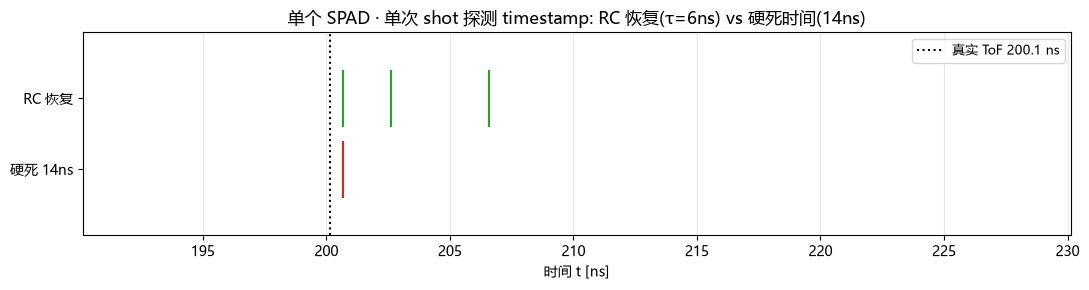

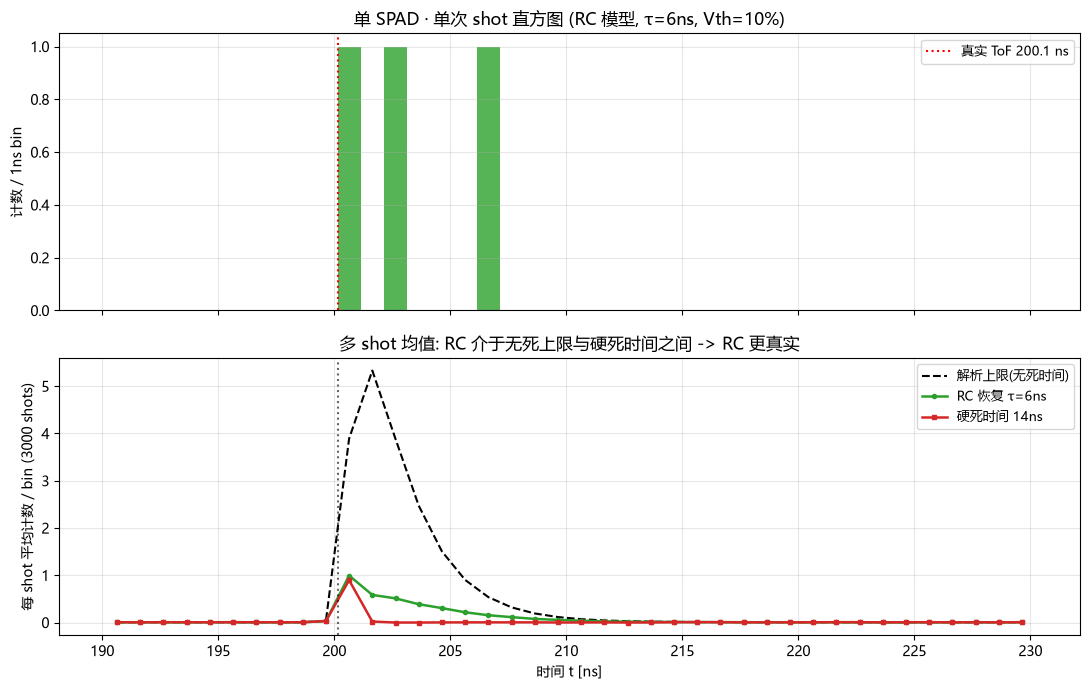

In [10]:
# ---- 时间窗(与 v12 相同, 参数不变) ----
t0 = time_of_flight(D0)
pre, post = 10e-9, 30e-9
dt_fine  = PARAMS["hist"]["dt_fine"]
bin_width = PARAMS["hist"]["bin_width"]
t_lo, t_hi = t0 - pre, t0 + post
tf = np.arange(t_lo, t_hi, dt_fine)

PDE = PARAMS["spad"]["PDE"]; jit = PARAMS["spad"]["jitter_sigma"]
t_dead = 14e-9                                # v12 硬死时间(作对照)

f_ij = fpix0[i0, j0]
r_sig = signal_photon_rate_fine(echo0, f_ij, tf)

# ---- (1) 单次 shot: RC vs 硬死时间(同 seed) ----
rng_rc  = np.random.default_rng(PARAMS["hist"]["seed"])
ev1_rc  = simulate_spad_shot_rc(r_sig, r_amb_ph, tf, PDE, TAU_RC, VTH_FRAC, jit, rng_rc, RESET)
rng_hd  = np.random.default_rng(PARAMS["hist"]["seed"])
ev1_hd  = simulate_spad_shot(r_sig, r_amb_ph, tf, PDE, t_dead, jit, rng_hd)
ev1_rc_ns = np.sort(ev1_rc)*1e9; ev1_hd_ns = np.sort(ev1_hd)*1e9
centers, c1_rc, edges = events_to_hist(ev1_rc, t_lo, t_hi, bin_width)
tc_ns = centers*1e9; t0_ns = t0*1e9

print("="*76)
print(f"单 SPAD (i0,j0)=({i0},{j0}), f_pix={f_ij:.3e}; 30m ToF={t0_ns:.1f} ns")
print(f"单次 shot: RC 模型探测 {ev1_rc.size} 个, 硬死时间(14ns)探测 {ev1_hd.size} 个")
print(f"  RC timestamp[ns]: " + (", ".join(f"{t:.2f}" for t in ev1_rc_ns) if ev1_rc.size else "(无)"))
print(f"  硬死 timestamp[ns]: " + (", ".join(f"{t:.2f}" for t in ev1_hd_ns) if ev1_hd.size else "(无)"))

# ---- (2) 多 shot 均值: RC / 硬死 / 无死上限 ----
Nrep = 3000
rng_a = np.random.default_rng(PARAMS["hist"]["seed"]+1)
rng_b = np.random.default_rng(PARAMS["hist"]["seed"]+1)
acc_rc = np.zeros(len(centers)); acc_hd = np.zeros(len(centers))
for _ in range(Nrep):
    e = simulate_spad_shot_rc(r_sig, r_amb_ph, tf, PDE, TAU_RC, VTH_FRAC, jit, rng_a, RESET)
    acc_rc += np.histogram(e, bins=edges)[0]
for _ in range(Nrep):
    e = simulate_spad_shot(r_sig, r_amb_ph, tf, PDE, t_dead, jit, rng_b)
    acc_hd += np.histogram(e, bins=edges)[0]
mc_rc = acc_rc/Nrep; mc_hd = acc_hd/Nrep

# 解析无死时间上限
r_det = (r_sig + r_amb_ph) * PDE
r_det = np.convolve(r_det, gaussian_kernel(jit, dt_fine), mode="same") * dt_fine
bin_idx = np.clip(((tf - t_lo)/bin_width).astype(int), 0, len(centers)-1)
lam = np.bincount(bin_idx, weights=r_det*dt_fine, minlength=len(centers))

print(f"窗口每 shot 总计数: 无死上限={lam.sum():.3f}, RC={mc_rc.sum():.3f}, 硬死14ns={mc_hd.sum():.3f}")
print(f"  -> RC 保留 {100*mc_rc.sum()/lam.sum():.1f}%, 硬死时间保留 {100*mc_hd.sum()/lam.sum():.1f}% (RC 更接近真实)")
pk = int(lam.argmax())
print(f"峰值 bin @ {tc_ns[pk]:.0f} ns: 无死={lam[pk]:.3f}, RC={mc_rc[pk]:.3f}, 硬死={mc_hd[pk]:.3f}")

# ---- 绘图 1: timestamp raster ----
fig, ax = plt.subplots(figsize=(11, 3.0))
ax.eventplot([ev1_rc_ns, ev1_hd_ns], lineoffsets=[2,1], linelengths=0.8,
             colors=["tab:green","tab:red"])
ax.axvline(t0_ns, color="k", ls=":", label=f"真实 ToF {t0_ns:.1f} ns")
ax.set_yticks([1,2]); ax.set_yticklabels(["硬死 14ns","RC 恢复"])
ax.set_xlim(t_lo*1e9, t_hi*1e9); ax.set_xlabel("时间 t [ns]")
ax.set_title(f"单个 SPAD · 单次 shot 探测 timestamp: RC 恢复(τ={TAU_RC*1e9:.0f}ns) vs 硬死时间(14ns)")
ax.legend(fontsize=9, loc="upper right"); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

# ---- 绘图 2: 直方图 + 均值对比 ----
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].bar(tc_ns, c1_rc, width=bin_width*1e9, align="center", color="tab:green", alpha=0.8)
ax[0].axvline(t0_ns, color="r", ls=":", label=f"真实 ToF {t0_ns:.1f} ns")
ax[0].set_ylabel("计数 / 1ns bin")
ax[0].set_title(f"单 SPAD · 单次 shot 直方图 (RC 模型, τ={TAU_RC*1e9:.0f}ns, Vth={VTH_FRAC*100:.0f}%)")
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

ax[1].plot(tc_ns, lam, "k--", lw=1.5, label="解析上限(无死时间)")
ax[1].plot(tc_ns, mc_rc, color="tab:green", lw=1.8, marker="o", ms=3, label=f"RC 恢复 τ={TAU_RC*1e9:.0f}ns")
ax[1].plot(tc_ns, mc_hd, color="tab:red", lw=1.8, marker="s", ms=3, label="硬死时间 14ns")
ax[1].axvline(t0_ns, color="k", ls=":", alpha=0.6)
ax[1].set_xlabel("时间 t [ns]"); ax[1].set_ylabel(f"每 shot 平均计数 / bin ({Nrep} shots)")
ax[1].set_title("多 shot 均值: RC 介于无死上限与硬死时间之间 -> RC 更真实")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 模块 9（v13 更新）— 阵列内不同 SPAD 的响应差异（RC 恢复模型）

像斑椭圆高斯 ⇒ 每个 SPAD 收集比例不同。用 RC 模型比较沿长边 y 不同偏移的 SPAD。
- **左**: 像元收集比例 f_pix 热图(聚焦被照区)。
- **右**: 沿长边 y 取中心/中段/边缘代表 SPAD, RC 模型下各自多 shot 平均计数-时间。

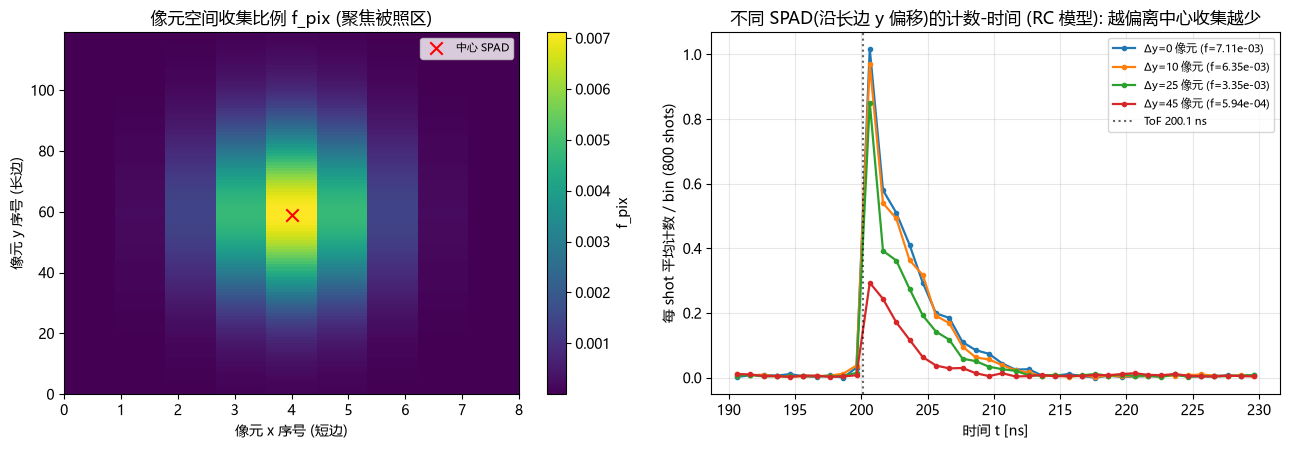

说明: RC 模型下, 中心 SPAD 因光子密集、恢复期部分灵敏, 计数比硬死时间高; 边缘 SPAD 光子稀疏, 两模型接近。


In [11]:
thr = fpix0.max() * 0.01
xs = np.where(fx0 > fx0.max()*0.01)[0]; ys = np.where(fy0 > fy0.max()*0.01)[0]
ix = slice(max(0, xs.min()-1), min(fpix0.shape[0], xs.max()+2))
iy = slice(max(0, ys.min()-1), min(fpix0.shape[1], ys.max()+2))
sub = fpix0[ix, iy]

offs = [0, 10, 25, 45]
offs = [d for d in offs if 0 <= j0 + d < fpix0.shape[1]]
reps = 800
rng9 = np.random.default_rng(PARAMS["hist"]["seed"] + 7)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
im = ax[0].imshow(sub.T, origin="lower", aspect="auto", cmap="viridis",
                  extent=[ix.start, ix.stop-1, iy.start, iy.stop-1])
ax[0].scatter([i0], [j0], c="r", marker="x", s=80, label="中心 SPAD")
ax[0].set_xlabel("像元 x 序号 (短边)"); ax[0].set_ylabel("像元 y 序号 (长边)")
ax[0].set_title("像元空间收集比例 f_pix (聚焦被照区)")
ax[0].legend(fontsize=8); plt.colorbar(im, ax=ax[0], label="f_pix")

for d in offs:
    j = j0 + d
    f_ij_d = fpix0[i0, j]
    r_sig_d = signal_photon_rate_fine(echo0, f_ij_d, tf)
    acc = np.zeros(len(centers))
    for _ in range(reps):
        ev = simulate_spad_shot_rc(r_sig_d, r_amb_ph, tf, PDE, TAU_RC, VTH_FRAC, jit, rng9, RESET)
        acc += np.histogram(ev, bins=edges)[0]
    ax[1].plot(tc_ns, acc/reps, lw=1.6, marker="o", ms=3,
               label=f"Δy={d} 像元 (f={f_ij_d:.2e})")
ax[1].axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
ax[1].set_xlabel("时间 t [ns]"); ax[1].set_ylabel(f"每 shot 平均计数 / bin ({reps} shots)")
ax[1].set_title("不同 SPAD(沿长边 y 偏移)的计数-时间 (RC 模型): 越偏离中心收集越少")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("说明: RC 模型下, 中心 SPAD 因光子密集、恢复期部分灵敏, 计数比硬死时间高; 边缘 SPAD 光子稀疏, 两模型接近。")

## 模块 10（沿用 v12）— Macro Pixel（宏像元）定义 9×3（仅文字说明与数值）

**定义**: 短边 x 的 9 个 SPAD 全取, 长边 y 每 3 个为一组。
阵列 `9×120` ⇒ 沿长边共 `120/3 = 40` 个宏像元, 每个 `9×3 = 27` 个 SPAD。
宏像元 `m` 覆盖全部 x、y 索引 `[3m, 3m+3)`。像斑长边 σ≈200µm ⇒ 中间宏像元信号多、两端仅底噪。

In [12]:
Bx_m, By_m = 9, 3
a = PARAMS["spad_array"]
assert a["Nx"] == Bx_m and a["Ny"] % By_m == 0
n_macro = a["Ny"] // By_m
n_pix_macro = Bx_m * By_m
macro_fsum = np.array([fpix0[:, m*By_m:(m+1)*By_m].sum() for m in range(n_macro)])
m_peak = int(macro_fsum.argmax())
print(f"宏像元 = {Bx_m}×{By_m}; 共 {n_macro} 个, 每个 {n_pix_macro} SPAD; 峰值宏像元 m_peak={m_peak} (Σf={macro_fsum[m_peak]:.3f})")
print(f"全部 Σf_pix={macro_fsum.sum():.3f}; 边缘 m=0 的 Σf={macro_fsum[0]:.3e} (近乎纯底噪)")

宏像元 = 9×3; 共 40 个, 每个 27 SPAD; 峰值宏像元 m_peak=20 (Σf=0.060)
全部 Σf_pix=0.997; 边缘 m=0 的 Σf=8.258e-04 (近乎纯底噪)


## 模块 11（v13 更新）— 逐-SPAD 蒙卡统计每个宏像元直方图（RC 恢复模型）

每个宏像元 27 个 SPAD 各自独立跑 **RC 引擎**(每 SPAD 各自 Vov 恢复), 合并事件后 1ns 直方图, 累加 N_shots。
同时给出 v12 硬死时间(14ns)的全体总计数做对比, 展示 RC 模型对计数损失的修正。

In [13]:
nbins = len(centers)
base_rate = signal_photon_rate_fine(echo0, 1.0, tf)
N_shots = PARAMS["hist"]["N_shots"]
macro_fvals = [fpix0[:, m*By_m:(m+1)*By_m].ravel() for m in range(n_macro)]

# ---- RC 模型: 逐-SPAD 蒙卡 ----
rng = np.random.default_rng(PARAMS["hist"]["seed"] + 11)
macro_hist = np.zeros((n_macro, nbins))
for _shot in range(N_shots):
    for m in range(n_macro):
        ev_all = []
        for fij in macro_fvals[m]:
            ev = simulate_spad_shot_rc(base_rate*fij, r_amb_ph, tf, PDE, TAU_RC, VTH_FRAC, jit, rng, RESET)
            if ev.size: ev_all.append(ev)
        if ev_all:
            macro_hist[m] += np.histogram(np.concatenate(ev_all), bins=edges)[0]

# ---- 硬死时间(14ns)对比: 只算全体总计数 ----
rng2 = np.random.default_rng(PARAMS["hist"]["seed"] + 11)
tot_hd = 0
for _shot in range(N_shots):
    for m in range(n_macro):
        for fij in macro_fvals[m]:
            ev = simulate_spad_shot(base_rate*fij, r_amb_ph, tf, PDE, t_dead, jit, rng2)
            tot_hd += ev.size

# ---- 解析上限(无死时间) ----
irf_k = gaussian_kernel(jit, dt_fine)
bin_idx = np.clip(((tf - t_lo)/bin_width).astype(int), 0, nbins-1)
macro_lam = np.zeros((n_macro, nbins))
for m in range(n_macro):
    r_det = (base_rate*macro_fsum[m] + n_pix_macro*r_amb_ph) * PDE
    r_det = np.convolve(r_det, irf_k, mode="same") * dt_fine
    macro_lam[m] = N_shots * np.bincount(bin_idx, weights=r_det*dt_fine, minlength=nbins)

tot_rc, tot_la = macro_hist.sum(), macro_lam.sum()
print("="*76)
print(f"逐-SPAD 蒙卡: {n_macro} 宏 × {n_pix_macro} SPAD × {N_shots} shots (RC: τ={TAU_RC*1e9:.0f}ns, Vth={VTH_FRAC*100:.0f}%)")
print(f"全体总计数: 无死上限={tot_la:.0f}, RC={tot_rc:.0f}, 硬死14ns={tot_hd:.0f}")
print(f"  -> 保留率: RC={100*tot_rc/tot_la:.1f}%, 硬死时间={100*tot_hd/tot_la:.1f}% (RC 高出 {tot_rc-tot_hd:.0f} 计数)")
print(f"峰值宏像元 m={m_peak}: RC 峰值 bin={macro_hist[m_peak].max():.0f}, 总计数={macro_hist[m_peak].sum():.0f}; "
      f"边缘 m=0 总计数={macro_hist[0].sum():.0f}")

逐-SPAD 蒙卡: 40 宏 × 27 SPAD × 10 shots (RC: τ=6ns, Vth=10%)
全体总计数: 无死上限=29666, RC=11165, 硬死14ns=6759
  -> 保留率: RC=37.6%, 硬死时间=22.8% (RC 高出 4406 计数)
峰值宏像元 m=20: RC 峰值 bin=130, 总计数=469; 边缘 m=0 总计数=78


## 模块 12（v13 更新）— 宏像元-时间热图（RC 模型）+ 峰值宏像元 27 SPAD timestamp

- **图 A**: 40 宏像元 × 时间(1ns bin) RC 模型计数热图。
- **图 B**: 代表性宏像元直方图(柱=RC 蒙卡, 虚线=无死上限参考)。
- **图 C**: 峰值宏像元单次 shot, 27 个 SPAD 各自 RC 探测 timestamp(每行一 SPAD)。

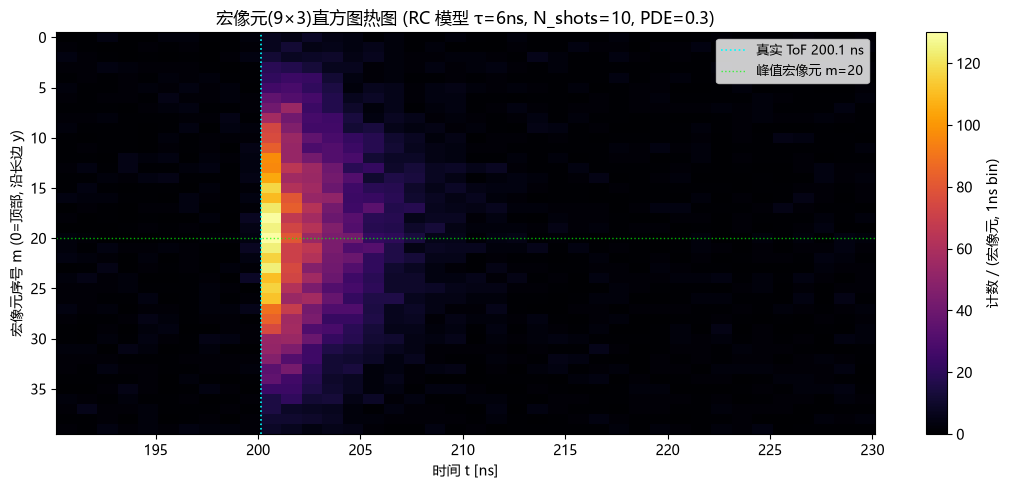

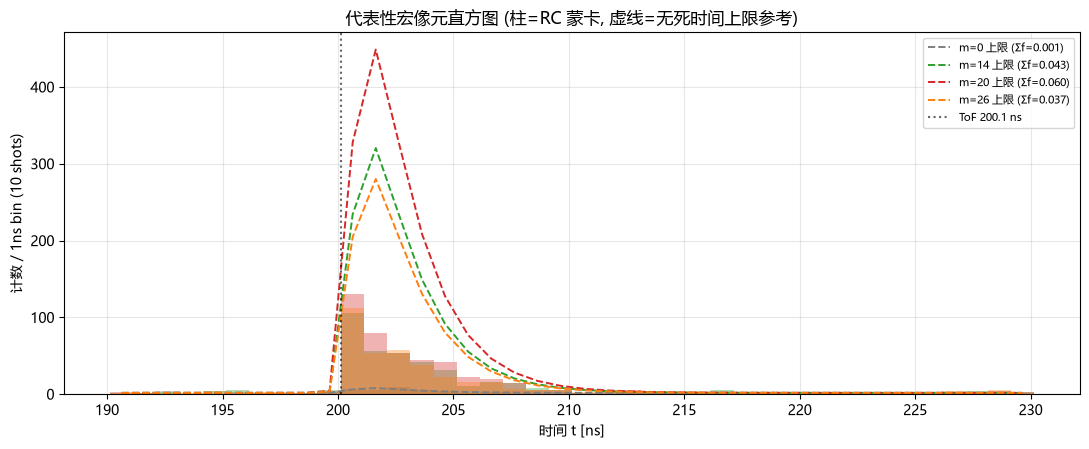

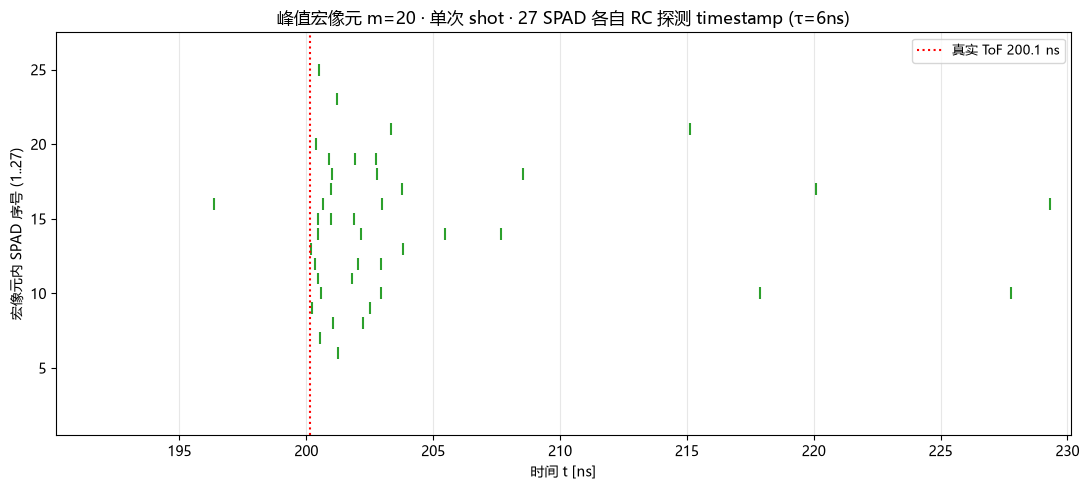

峰值宏像元 m=20 单次 shot(RC): 27 个 SPAD 共探测 42 个光子。
每个 SPAD 各自 Vov 按 RC 恢复(τ=6ns), 恢复期渐变灵敏, 合并后 1ns 直方图。


In [14]:
# ---- 图 A: 热图 ----
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(macro_hist, origin="upper", aspect="auto", cmap="inferno",
               extent=[tc_ns[0]-0.5, tc_ns[-1]+0.5, n_macro-0.5, -0.5])
ax.axvline(t0_ns, color="cyan", ls=":", lw=1.2, label=f"真实 ToF {t0_ns:.1f} ns")
ax.axhline(m_peak, color="lime", ls=":", lw=1.0, alpha=0.7, label=f"峰值宏像元 m={m_peak}")
ax.set_xlabel("时间 t [ns]"); ax.set_ylabel("宏像元序号 m (0=顶部, 沿长边 y)")
ax.set_title(f"宏像元(9×3)直方图热图 (RC 模型 τ={TAU_RC*1e9:.0f}ns, N_shots={N_shots}, PDE={PDE})")
ax.legend(fontsize=9, loc="upper right"); plt.colorbar(im, ax=ax, label="计数 / (宏像元, 1ns bin)")
plt.tight_layout(); plt.show()

# ---- 图 B: 代表性宏像元直方图 ----
fig, ax = plt.subplots(figsize=(11, 4.6))
reps_m = sorted(set([0, max(0, m_peak-6), m_peak, min(n_macro-1, m_peak+6)]))
colors = ["tab:gray", "tab:green", "tab:red", "tab:orange", "tab:purple"]
for m, c in zip(reps_m, colors):
    ax.bar(tc_ns, macro_hist[m], width=bin_width*1e9, align="center", alpha=0.35, color=c)
    ax.plot(tc_ns, macro_lam[m], color=c, lw=1.4, ls="--", label=f"m={m} 上限 (Σf={macro_fsum[m]:.3f})")
ax.axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
ax.set_xlabel("时间 t [ns]"); ax.set_ylabel(f"计数 / 1ns bin ({N_shots} shots)")
ax.set_title("代表性宏像元直方图 (柱=RC 蒙卡, 虚线=无死时间上限参考)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- 图 C: 峰值宏像元 27 SPAD RC timestamp ----
rng_ts = np.random.default_rng(PARAMS["hist"]["seed"] + 200)
sp_events = []
for fij in macro_fvals[m_peak]:
    ev = simulate_spad_shot_rc(base_rate*fij, r_amb_ph, tf, PDE, TAU_RC, VTH_FRAC, jit, rng_ts, RESET)
    sp_events.append(np.sort(ev)*1e9)
n_ev_total = sum(len(e) for e in sp_events)

fig, ax = plt.subplots(figsize=(11, 5))
ax.eventplot(sp_events, lineoffsets=np.arange(1, n_pix_macro+1), linelengths=0.8, colors="tab:green")
ax.axvline(t0_ns, color="r", ls=":", label=f"真实 ToF {t0_ns:.1f} ns")
ax.set_xlim(t_lo*1e9, t_hi*1e9); ax.set_ylim(0.5, n_pix_macro+0.5)
ax.set_xlabel("时间 t [ns]"); ax.set_ylabel("宏像元内 SPAD 序号 (1..27)")
ax.set_title(f"峰值宏像元 m={m_peak} · 单次 shot · 27 SPAD 各自 RC 探测 timestamp (τ={TAU_RC*1e9:.0f}ns)")
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

print(f"峰值宏像元 m={m_peak} 单次 shot(RC): 27 个 SPAD 共探测 {n_ev_total} 个光子。")
print(f"每个 SPAD 各自 Vov 按 RC 恢复(τ={TAU_RC*1e9:.0f}ns), 恢复期渐变灵敏, 合并后 1ns 直方图。")